<a href="https://colab.research.google.com/github/pkprajapati7402/Loan-Approval-Predictor/blob/main/LoanApprovalPrediction_PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv
Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.79        57
           1       0.74      0.60      0.67        43

    accuracy                           0.74       100
   macro avg       0.74      0.72      0.73       100
weighted avg       0.74      0.74      0.74       100



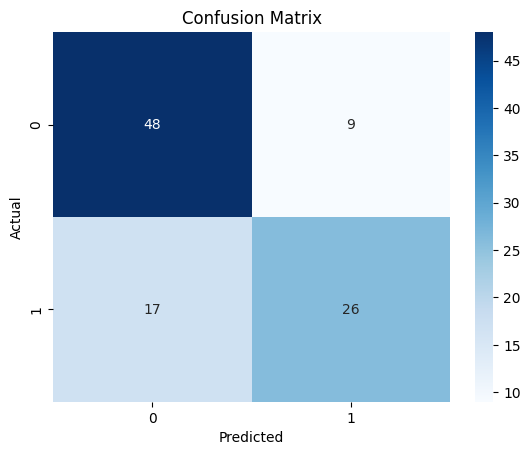

Loan Approval Status for New Applicant: Rejected


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 2: Load dataset
# Upload the dataset in Colab or mount Google Drive
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("loan_approval_dataset.csv")
df.head()

# Step 3: Data preprocessing
# Encode categorical variables
le = LabelEncoder()
df['Employment_Type'] = le.fit_transform(df['Employment_Type'])  # Salaried=2, Self-employed=1, Unemployed=0
df['Loan_Status'] = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

# Step 4: Feature selection
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Step 5: Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 7: Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 8: Evaluate the model
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 9: Predict for a new applicant
new_applicant = [[30, 50000, 700, le.transform(['Salaried'])[0], 100000, 36, 1]]
new_applicant_scaled = scaler.transform(new_applicant)
prediction = model.predict(new_applicant_scaled)

print("Loan Approval Status for New Applicant:", "Approved" if prediction[0] == 1 else "Rejected")


First 5 rows of the dataset:
   Age  Income  Credit_Score Employment_Type  Loan_Amount  Loan_Term_Months  \
0   59  104076           842   Self-employed       498948                36   
1   49  109780           339        Salaried       312257                60   
2   35   41545           528   Self-employed        79069                48   
3   28   41689           847   Self-employed       234189                12   
4   41   31174           522        Salaried       403465                60   

   Existing_Loans Loan_Status  
0               1    Approved  
1               0    Rejected  
2               4    Approved  
3               3    Approved  
4               1    Rejected  

Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.79        57
           1       0.74      0.60      0.67        43

    accuracy                           0.74       100
   macro avg       0.74      0.72      0.73  

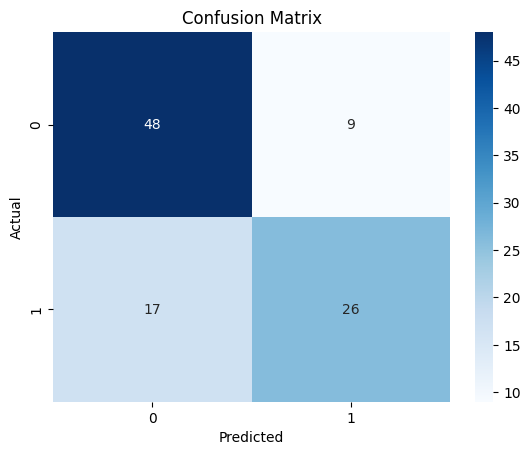


Enter applicant details:
Age (21–60): 35
Monthly Income (20,000 – 150,000): 80000
Credit Score (300–900): 600
Employment Type (Salaried/Self-employed/Unemployed): Self-employed
Loan Amount (5,000 – 500,000): 300000
Loan Term in Months (12/24/36/48/60): 24
Number of Existing Loans (0–4): 0

Loan Approval Status: ❌ Rejected


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load dataset (file already present)
df = pd.read_csv("loan_approval_dataset.csv")
print("First 5 rows of the dataset:")
print(df.head())

# Step 3: Data preprocessing
le = LabelEncoder()
df['Employment_Type'] = le.fit_transform(df['Employment_Type'])  # Salaried=2, Self-employed=1, Unemployed=0
df['Loan_Status'] = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

# Step 4: Feature selection
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Step 5: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 7: Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 8: Evaluate model
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 9: Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 10: User input for prediction
print("\nEnter applicant details:")
age = int(input("Age (21–60): "))
income = int(input("Monthly Income (20,000 – 150,000): "))
credit_score = int(input("Credit Score (300–900): "))
employment_type = input("Employment Type (Salaried/Self-employed/Unemployed): ")
loan_amount = int(input("Loan Amount (5,000 – 500,000): "))
loan_term = int(input("Loan Term in Months (12/24/36/48/60): "))
existing_loans = int(input("Number of Existing Loans (0–4): "))

# Step 11: Process and predict
emp_encoded = le.transform([employment_type])[0]
user_data = [[age, income, credit_score, emp_encoded, loan_amount, loan_term, existing_loans]]
user_scaled = scaler.transform(user_data)
result = model.predict(user_scaled)

print("\nLoan Approval Status:", "✅ Approved" if result[0] == 1 else "❌ Rejected")
